# K-Means Clustering on O*NET Career Data (Scaled)

This notebook applies **K-Means clustering** to group similar occupations based on their required skills and abilities. We use **scaled data** (standardized) to ensure all features contribute equally to the clustering.

**Key steps:**
1. Load and scale the data
2. Apply PCA for visualization and understanding
3. Find the optimal number of clusters (Elbow Method)
4. Run K-Means clustering
5. Evaluate results with Silhouette Score

## 1. Import Libraries

Libraries for data handling, visualization, and machine learning clustering.

In [22]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning tools
from sklearn.preprocessing import StandardScaler  # Standardizes features (mean=0, std=1)
from sklearn.decomposition import PCA             # Reduces dimensions for visualization
from sklearn.cluster import KMeans                # The main clustering algorithm
from scipy.spatial.distance import cdist          # Calculates distances for elbow method

## 2. Initialize Preprocessing Tools

We create instances of StandardScaler and PCA that will be used later.

In [23]:
scaler = StandardScaler()
pca = PCA()

## 3. Load the Prepared Data

Load the dataset created in the Data Preparation notebook. This contains all occupations with their skill and ability ratings.

In [24]:
# Load the preprocessed career data (from DataLoad&Prep notebook) - change path if needed
full_df = pd.read_csv('../Data/career_pivot_results.csv')
print('Full Data Frame')
print(full_df.head())

Full Data Frame
  O*NET-SOC Code                                Title  A: Arm-Hand Steadiness  \
0     11-1011.00                     Chief Executives                    0.50   
1     11-1011.03        Chief Sustainability Officers                    0.00   
2     11-1021.00      General and Operations Managers                    0.88   
3     11-2011.00  Advertising and Promotions Managers                    0.50   
4     11-2021.00                   Marketing Managers                    0.12   

   A: Auditory Attention  A: Category Flexibility  A: Control Precision  \
0                   2.00                     4.00                  0.75   
1                   1.75                     3.50                  0.50   
2                   2.00                     3.25                  0.12   
3                   1.25                     3.88                  0.12   
4                   1.62                     3.62                  0.00   

   A: Deductive Reasoning  A: Depth Perception

## 4. Extract Numeric Features

We extract just the skill/ability columns (excluding job codes and titles) as our feature matrix X.

In [25]:
# Select only numeric columns (skills and abilities ratings)
numeric_df = full_df.select_dtypes(include=[np.number])
X = numeric_df.values  # Convert to numpy array

print(f"Shape: {X.shape}")  # (number of jobs, number of features)
print(f"Numeric columns: {numeric_df.columns.tolist()[:5]}...")

Shape: (894, 87)
Numeric columns: ['A: Arm-Hand Steadiness', 'A: Auditory Attention', 'A: Category Flexibility', 'A: Control Precision', 'A: Deductive Reasoning']...


## 5. Scale the Data

**StandardScaler** transforms each feature to have:
- Mean = 0
- Standard deviation = 1

In [26]:
# Apply standardization: fit the scaler to data and transform it
X_scaled = scaler.fit_transform(X)

# Compare original vs scaled values
print("Original First Value:", X[0][0]) 
print("Scaled First Value:", X_scaled[0][0])  # Z-score: (value - mean) / std

# Verify scaling worked
print("New Mean:", X_scaled.mean().round(2))
print("New Std:", X_scaled.std().round(2))

Original First Value: 0.5
Scaled First Value: -1.4187069226581608
New Mean: 0.0
New Std: 1.0


## 6. PCA Analysis - Understanding the Data Structure

**Principal Component Analysis (PCA)** reduces our features into fewer "principal components" that capture most of the variance in the data.

The **Scree Plot** shows how much variance each component explains. We look for the "elbow" where adding more components gives diminishing returns.

Variance explained by PC1: 47.49%
Variance explained by PC2: 18.95%
Variance explained by PC3: 6.16%
Total variance with 2 components: 66.44%
Total variance with 3 components: 72.60%


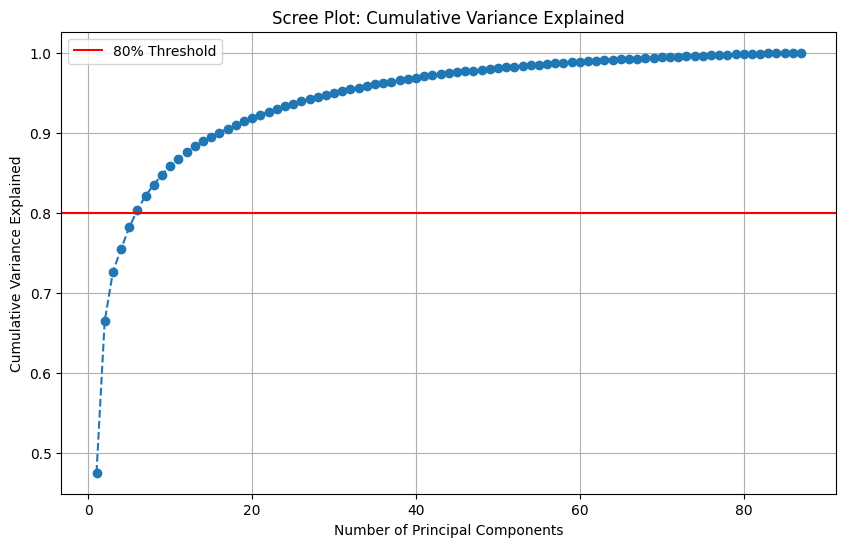

In [27]:
# Fit PCA to the scaled data
pca.fit(X_scaled)

# Get the variance explained by each component
evr = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(evr)  # Running total of variance explained

# Print how much each of the first 3 components explains
print(f"Variance explained by PC1: {evr[0]:.2%}")
print(f"Variance explained by PC2: {evr[1]:.2%}")
print(f"Variance explained by PC3: {evr[2]:.2%}")
print(f"Total variance with 2 components: {cumulative_variance[1]:.2%}")
print(f"Total variance with 3 components: {cumulative_variance[2]:.2%}")

# Scree Plot: visualize cumulative variance explained
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(evr) + 1), cumulative_variance, marker='o', linestyle='--')
plt.axhline(y=0.80, color='r', linestyle='-', label='80% Threshold')
plt.title('Scree Plot: Cumulative Variance Explained')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Variance Explained')
plt.grid(True)
plt.legend()
plt.show()

### 6.1 Interpreting Principal Components

**Loadings** tell us which original features (skills/abilities) contribute most to each principal component. 

- **Positive loadings**: High values in that skill push the component score UP
- **Negative loadings**: High values push the component score DOWN

This helps us understand what each component "means" - e.g., PC1 might represent "cognitive skills" vs "physical skills".

In [28]:
# Get feature names for interpretation
feature_names = numeric_df.columns

# Create a DataFrame of loadings (how much each feature contributes to each PC)
loadings = pd.DataFrame(
    pca.components_, 
    columns=feature_names,
    index=[f'PC{i+1}' for i in range(len(pca.components_))]
)

def interpret_component(pc_name):
    """Show the top positive and negative contributors to a principal component"""
    print(f"*** {pc_name} Interpretation ***")
    
    # Strongest positive contributors (skills that increase this PC)
    top_pos = loadings.loc[pc_name].nlargest(5)
    print("Top Positive (High Values):")
    print(top_pos)
    print("-" * 20)
    
    # Strongest negative contributors (skills that decrease this PC)
    top_neg = loadings.loc[pc_name].nsmallest(5)
    print("Top Negative (Low Values):")
    print(top_neg)
    print("\n")

# Interpret the first 3 principal components
interpret_component('PC1')
interpret_component('PC2')
interpret_component('PC3')

*** PC1 Interpretation ***
Top Positive (High Values):
S: Reading Comprehension    0.143484
A: Written Expression       0.143380
S: Writing                  0.143126
S: Speaking                 0.142439
S: Active Listening         0.141503
Name: PC1, dtype: float64
--------------------
Top Negative (Low Values):
A: Extent Flexibility       -0.130770
A: Static Strength          -0.129577
A: Dynamic Strength         -0.128630
A: Multilimb Coordination   -0.127266
A: Trunk Strength           -0.124234
Name: PC1, dtype: float64


*** PC2 Interpretation ***
Top Positive (High Values):
A: Perceptual Speed            0.190247
A: Visualization               0.182574
A: Flexibility of Closure      0.175960
S: Operations Monitoring       0.175934
S: Quality Control Analysis    0.174934
Name: PC2, dtype: float64
--------------------
Top Negative (Low Values):
S: Service Orientation     -0.003289
A: Speech Clarity           0.008012
A: Speech Recognition       0.013124
S: Social Perceptiveness    

### 6.2 Visualizing Feature Loadings

A heatmap showing which skills define each principal component.

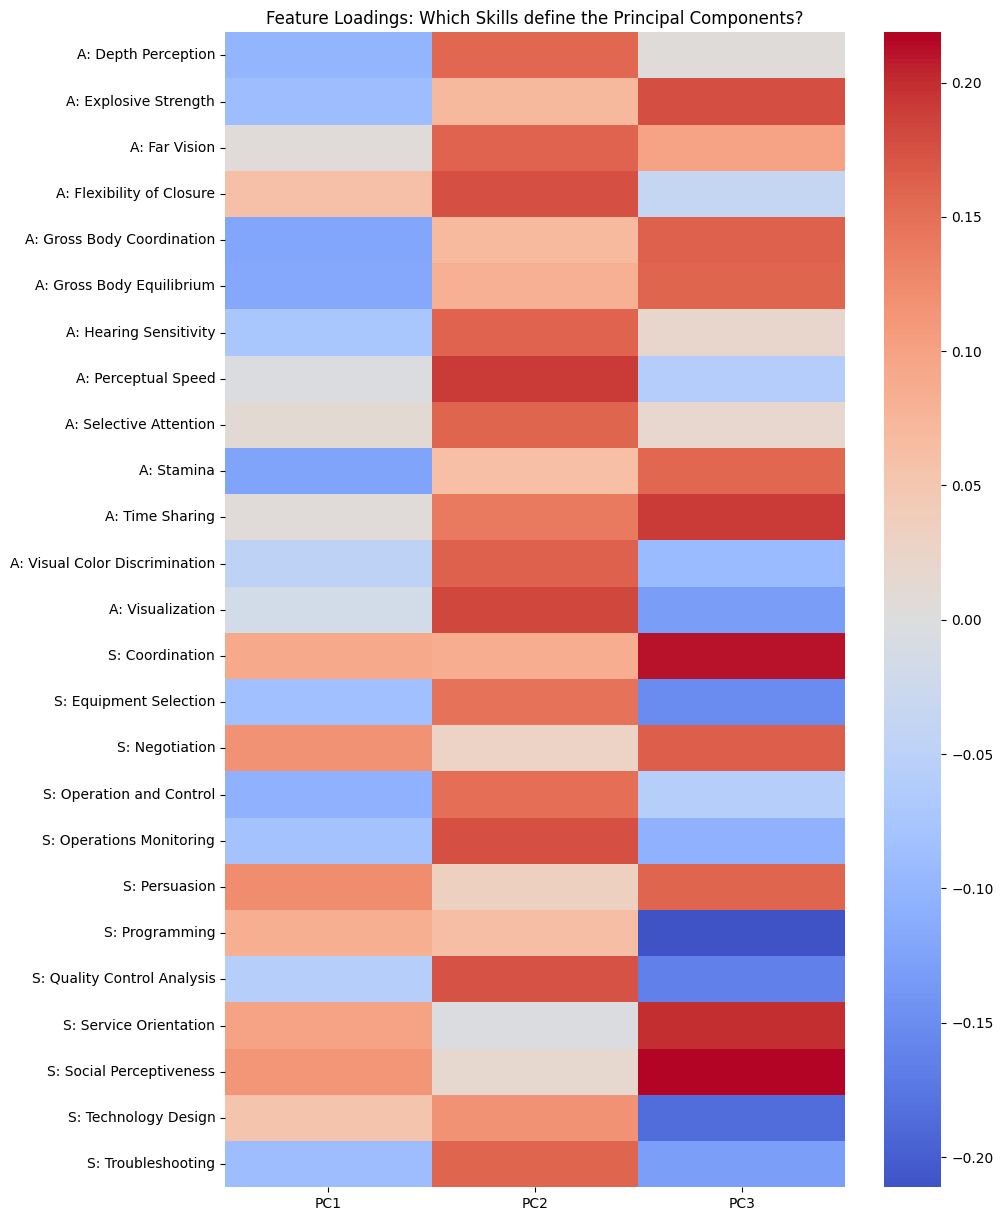

In [29]:
# Visualize how features relate to the top 3 principal components
plt.figure(figsize=(10, 15))

# Select only the top 3 PCs and transpose for better visualization
subset = loadings.iloc[:3].T 

# Filter: keep only features with at least one strong loading (|loading| > 0.15)
filtered_subset = subset[(subset.abs() > 0.15).any(axis=1)]

# Create heatmap: red = positive contribution, blue = negative
sns.heatmap(filtered_subset, cmap='coolwarm', center=0, annot=False)
plt.title("Feature Loadings: Which Skills define the Principal Components?")
plt.show()

## 7. Visualizing the Data in 2D Space

We reduce the data to 2 dimensions using PCA so we can visualize it. Each point represents one occupation. Jobs that appear close together have similar skill/ability profiles.

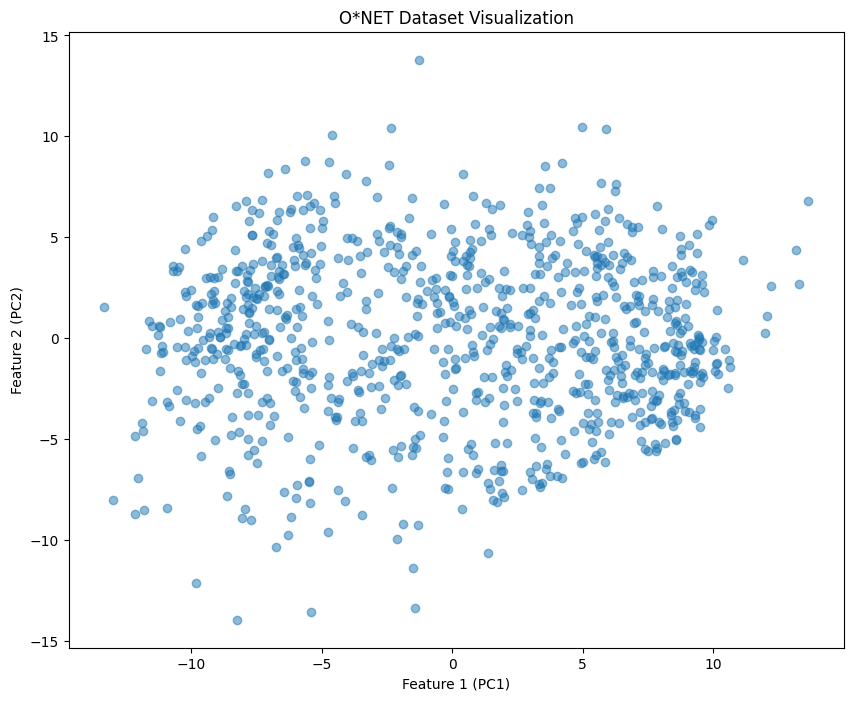

In [30]:
# Reduce to 2 dimensions for visualization
pca_simple = PCA(n_components=2)
coords = pca_simple.fit_transform(X_scaled)

# Extract the two principal components as x and y coordinates
x1 = coords[:, 0]  
x2 = coords[:, 1]

# Scatter plot of all occupations in 2D PCA space
plt.figure(figsize=(10, 8))
plt.scatter(x1, x2, marker='o', alpha=0.5)

plt.title('O*NET Dataset Visualization')
plt.xlabel('Feature 1 (PC1)')
plt.ylabel('Feature 2 (PC2)')
plt.show()

## 8. Finding the Optimal Number of Clusters (Elbow Method)

**The key question**: How many clusters (k) should we use?

The **Elbow Method** helps us decide by plotting cluster quality metrics for different values of k:
- **Distortion**: Average squared distance from each point to its cluster center
- **Inertia**: Sum of squared distances

We look for the "elbow" - the point where adding more clusters stops significantly improving the results.

In [31]:
# Test different values of k (1 to 19 clusters)
distortions = []  # Average squared distance to cluster center
inertias = []     # Sum of squared distances (sklearn's built-in metric)
mapping1 = {}     # Store distortion for each k
mapping2 = {}     # Store inertia for each k
K = range(1, 20)

for k in K:
    # Fit K-Means with current k value
    # n_init=20: run 20 times with different starting points, keep best result
    # random_state=42: ensures reproducible results
    kmeanModel = KMeans(n_clusters=k, n_init=20, random_state=42).fit(X_scaled)
    
    # Calculate distortion: average squared distance from points to their cluster centers
    distortions.append(sum(np.min(cdist(X_scaled, kmeanModel.cluster_centers_, 'euclidean'), axis=1)**2) / X_scaled.shape[0])
    inertias.append(kmeanModel.inertia_)
    
    mapping1[k] = distortions[-1]
    mapping2[k] = inertias[-1]

### 8.1 Elbow Plot - Distortion

Distortion measures how spread out the points are within each cluster. We want to find where the improvement slows down.

Distortion values:
1 : 87.00000000000011
2 : 55.13974379575044
3 : 48.55091296050961
4 : 43.003250255818074
5 : 39.7305054380461
6 : 37.299752695569865
7 : 35.669784617200925
8 : 34.226144865149855
9 : 33.1767783202242
10 : 32.22679927357112
11 : 31.403739796142048
12 : 30.512406378868988
13 : 29.887837362300058
14 : 29.29797896823961
15 : 28.725716697204028
16 : 28.25299378651445
17 : 27.684821579323845
18 : 27.386758884607413
19 : 26.888484896349983


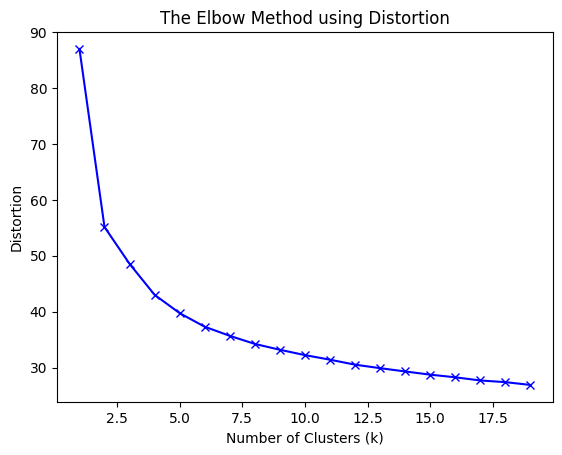

In [32]:
# Print distortion values for each k
print("Distortion values:")
for key, val in mapping1.items():
    print(f'{key} : {val}')

# Plot the elbow curve for distortion
plt.plot(K, distortions, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Distortion')
plt.title('The Elbow Method using Distortion')
plt.show()

### 8.2 Elbow Plot - Inertia

Inertia is sklearn's built-in metric — the sum of squared distances from points to their cluster centers. It tells the same story as distortion but on a different scale.

Inertia values:
1 : 77777.99999999999
2 : 49294.93095340087
3 : 43404.51618669561
4 : 38444.90572870138
5 : 35519.071861613214
6 : 33345.97890983952
7 : 31888.787447777635
8 : 30598.17350944399
9 : 29660.039818280446
10 : 28810.758550572573
11 : 28074.943377751035
12 : 27278.091302708846
13 : 26719.726601896255
14 : 26192.393197606198
15 : 25680.79072730042
16 : 25258.176445143956
17 : 24750.23049191553
18 : 24483.76244283903
19 : 24038.305497336896


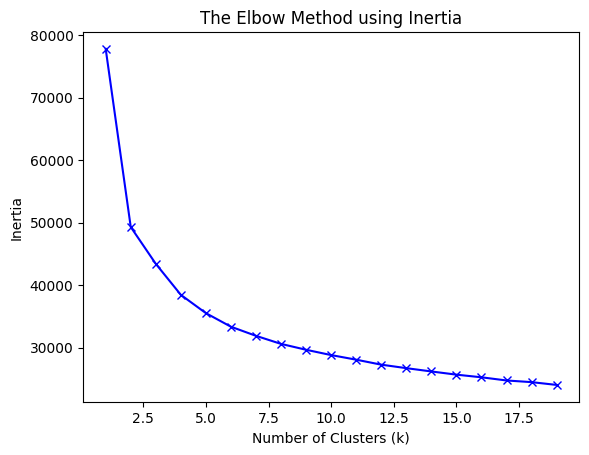

In [33]:
# Print inertia values for each k
print("Inertia values:")
for key, val in mapping2.items():
    print(f'{key} : {val}')

# Plot the elbow curve for inertia
plt.plot(K, inertias, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('The Elbow Method using Inertia')
plt.show()

## 9. Manual K-Means Implementation

To understand how K-Means works internally, we implement it step by step for this file (later on we use the predefined function):

**K-Means Algorithm Steps:**
1. **Initialize**: Place k random centroids in the feature space
2. **Assign**: Assign each point to its nearest centroid
3. **Update**: Move each centroid to the mean of its assigned points
4. Repeat steps 2-3 until centroids stop moving

In [34]:
# Manual K-Means: Initialize random centroids
k = 7  # Number of clusters (based on elbow method)

clusters = {}
np.random.seed(42)  # For reproducibility

# Create k clusters with random center positions
for idx in range(k):
    center = 2 * (2 * np.random.random((X_scaled.shape[1],)) - 1)
    
    cluster = {
        'center': center,   
        'points': []        
    }
    clusters[idx] = cluster
    
clusters  # Show initial cluster structure

{0: {'center': array([-0.50183952,  1.80285723,  0.92797577,  0.39463394, -1.37592544,
         -1.37602192, -1.76766555,  1.46470458,  0.40446005,  0.83229031,
         -1.91766202,  1.87963941,  1.32977056, -1.15064356, -1.27270013,
         -1.26638196, -0.78303103,  0.09902573, -0.27221993, -0.83508344,
          0.44741158, -1.44202456, -0.83142141, -0.53455263, -0.17572006,
          1.14070385, -1.20130487,  0.05693775,  0.36965828, -1.81419835,
          0.43017941, -1.31790351, -1.73979363,  1.79554215,  1.86252813,
          1.23358939, -0.78154492, -1.60931154,  0.73693211, -0.23939003,
         -1.51184706, -0.01929236, -1.86244592,  1.63728161, -0.96488007,
          0.65008914, -0.7531557 ,  0.08027208,  0.18684112, -1.26058218,
          1.87833851,  1.10053129,  1.75799577,  1.5793094 ,  0.39159992,
          1.68749694, -1.64602999, -1.21606855, -1.81909084, -0.69867868,
         -0.44529084, -0.91460387,  1.31495004, -0.57298669, -0.87626196,
          0.17078433, -1.

### 9.1 Visualize Initial Random Centroids

The red stars show our randomly placed initial centroids. The algorithm will move these to find natural cluster centers.

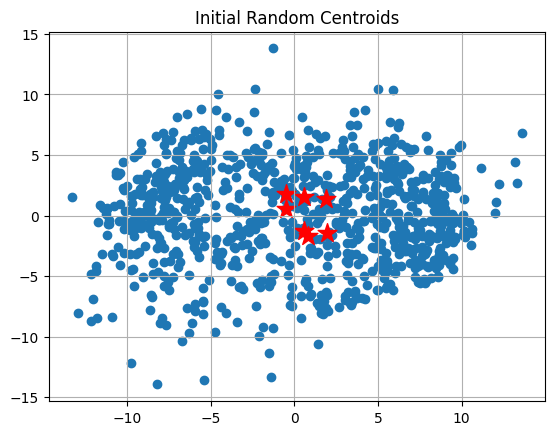

In [35]:
# Plot data points with initial random centroids
plt.scatter(x1, x2)
plt.grid(True)

# Plot each centroid as a red star
for i in clusters:
    center = clusters[i]['center']
    plt.scatter(center[0], center[1], marker='*', c='red', s=200)
    
plt.title('Initial Random Centroids')
plt.show()

### 9.2 Define Helper Functions

We need functions to:
1. Calculate **distance** between points (Euclidean distance)
2. **Assign** each point to its nearest cluster
3. **Update** cluster centers to the mean of assigned points
4. **Predict** cluster labels for any data point

In [36]:
# Euclidean distance: sqrt(sum of squared differences)
def distance(p1, p2):
    return np.sqrt(np.sum((p1 - p2)**2))

In [37]:
def assign_clusters(X, clusters):
    """Assign each data point to its nearest cluster center"""
    for idx in range(X.shape[0]):
        dist = []
        curr_x = X[idx]  # Current data point
        
        # Calculate distance to each cluster center
        for i in range(k):
            dis = distance(curr_x, clusters[i]['center'])
            dist.append(dis)
        
        # Assign to nearest cluster (smallest distance)
        curr_cluster = np.argmin(dist)
        clusters[curr_cluster]['points'].append(curr_x)
    return clusters

def update_clusters(X, clusters):
    """Move each cluster center to the mean of its assigned points"""
    for i in range(k):
        points = np.array(clusters[i]['points'])
        if points.shape[0] > 0:
            # New center = average position of all points in cluster
            new_center = points.mean(axis=0)
            clusters[i]['center'] = new_center
            clusters[i]['points'] = []  # Clear points for next iteration
    return clusters

In [38]:
def pred_cluster(X, clusters):
    """Predict cluster label for each data point based on final centroids"""
    pred = []
    for i in range(X.shape[0]):
        dist = []
        # Find distance to each cluster center
        for j in range(k):
            dist.append(distance(X[i], clusters[j]['center']))
        # Assign to nearest cluster
        pred.append(np.argmin(dist))
    return pred

### 9.3 Run K-Means Until Convergence

Run the assign → update loop repeatedly until centroids stop moving (convergence).

In [39]:
# Run K-Means until convergence
max_iterations = 100
tolerance = 1e-4  # Convergence threshold

for iteration in range(max_iterations):
    # Store old centers to check for convergence
    old_centers = np.array([clusters[i]['center'].copy() for i in range(k)])
    
    # Step 1: Assign each point to nearest centroid
    clusters = assign_clusters(X_scaled, clusters)
    
    # Step 2: Move centroids to cluster means
    clusters = update_clusters(X_scaled, clusters)
    
    # Get new centers
    new_centers = np.array([clusters[i]['center'] for i in range(k)])
    
    # Check convergence: if centroids barely moved, stop
    center_shift = np.sqrt(np.sum((new_centers - old_centers)**2))
    
    if center_shift < tolerance:
        print(f"Converged after {iteration + 1} iterations!")
        break
else:
    print(f"Reached max iterations ({max_iterations})")

print(f"Final centroid shift: {center_shift:.6f}")

# Get final cluster labels
pred = pred_cluster(X_scaled, clusters)

Converged after 13 iterations!
Final centroid shift: 0.000000


### 9.4 Visualize Results After Convergence

Points are colored by their assigned cluster from our manual K-Means implementation.

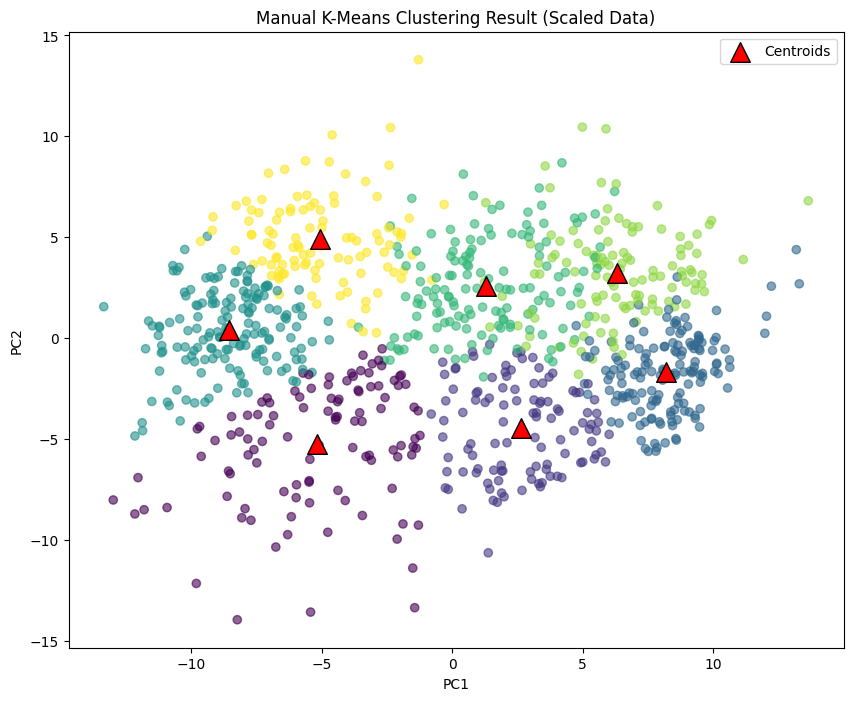

In [40]:
# Plot results: points colored by cluster assignment from manual K-Means
plt.figure(figsize=(10, 8))
plt.scatter(x1, x2, c=pred, cmap='viridis', alpha=0.6)

# Transform manual centroids to 2D PCA space (same space as the data points)
manual_centroids = np.array([clusters[i]['center'] for i in range(k)])
centroids_2d = pca_simple.transform(manual_centroids)

# Show centroid positions as red triangles
plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1], marker='^', c='red', s=200, edgecolors='black', label='Centroids')

plt.title('Manual K-Means Clustering Result (Scaled Data)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

### 9.5 Explore Cluster Contents

View the top 5 largest clusters and sample 8 jobs from each to understand what types of occupations are grouped together.

In [41]:
# Add cluster labels to the dataframe (using manual K-Means results)
full_df['Scaled_KMeans_Cluster'] = pred

# Get cluster sizes and identify top 5 largest clusters
cluster_sizes = full_df['Scaled_KMeans_Cluster'].value_counts().sort_values(ascending=False)
top_5_clusters = cluster_sizes.head(5).index.tolist()

print("Top 5 Largest Clusters:")
print(cluster_sizes.head(5))
print("\n" + "="*60 + "\n")

# Show top 8 jobs from each of the top 5 clusters
for cluster_id in top_5_clusters:
    cluster_jobs = full_df[full_df['Scaled_KMeans_Cluster'] == cluster_id]['Title']
    
    print(f"CLUSTER {cluster_id} ({len(cluster_jobs)} jobs)")
    print("-" * 40)
    
    # Show first 8 jobs in this cluster
    for i, job in enumerate(cluster_jobs.head(8), 1):
        print(f"  {i}. {job}")
    
    print("\n")

Top 5 Largest Clusters:
Scaled_KMeans_Cluster
3    161
2    153
4    143
5    116
1    109
Name: count, dtype: int64


CLUSTER 3 (161 jobs)
----------------------------------------
  1. Athletes and Sports Competitors
  2. Medical Equipment Preparers
  3. Parking Enforcement Workers
  4. Security Guards
  5. Landscaping and Groundskeeping Workers
  6. Pesticide Handlers, Sprayers, and Applicators, Vegetation
  7. Tree Trimmers and Pruners
  8. Motion Picture Projectionists


CLUSTER 2 (153 jobs)
----------------------------------------
  1. Chief Executives
  2. Chief Sustainability Officers
  3. General and Operations Managers
  4. Advertising and Promotions Managers
  5. Marketing Managers
  6. Sales Managers
  7. Fundraising Managers
  8. Financial Managers


CLUSTER 4 (143 jobs)
----------------------------------------
  1. Administrative Services Managers
  2. Facilities Managers
  3. Security Managers
  4. Industrial Production Managers
  5. Geothermal Production Managers
  6. Bi

## 10. Evaluate Clustering Quality: Silhouette Score

The **Silhouette Score** measures how well-defined the clusters are:
- Ranges from -1 to +1
- **+1**: Points are well-matched to their own cluster and poorly-matched to others (good!)
- **0**: Points are on cluster boundaries
- **-1**: Points may be assigned to the wrong cluster


In [42]:
from sklearn.metrics import silhouette_score

# Calculate silhouette score using manual K-Means cluster labels
score = silhouette_score(X_scaled, pred)

print(f"Silhouette Score: {score:.3f}")

Silhouette Score: 0.140


---

## 📋 Summary: K-Means Clustering (Scaled Data)

### Best Parameters Found
| Parameter | Value | How Determined |
|-----------|-------|----------------|
| **Number of Clusters (k)** | 7 | Elbow method (distortion/inertia curves) |
| **Scaling** | StandardScaler (Z-score) | Required for distance-based algorithms |
| **Initialization** | Random | Manual implementation |
| **Convergence** | Until centroids stop moving | Tolerance = 1e-4 |

### Evaluation Metrics
- **Silhouette Score:** Measures cluster separation (closer to 1 = better)
- **Inertia/Distortion:** Measures within-cluster compactness (lower = better)

### Limitations
- K-Means assumes spherical clusters of similar size
- Sensitive to initial centroid placement
- The "elbow" in the elbow method can be subjective
- 2D visualization (PC1 vs PC2) only shows ~40% of variance

### Next Steps
- Apply PCA before clustering to reduce noise(file 03_K-means-PCA)
- Compare with unscaled version to see the impact of preprocessing (file 04_K-mean_unscaled)
- Try hierarchical clustering for dendrogram visualization(file 05_Hierarchical_Clustering)